# Simulación de Producción y Drift
## Sección P — Demostrar que el sistema detecta cambios en P(X)

Este notebook simula el paso del tiempo en producción, dividiendo el dataset en 4 partes conceptuales:

**REFERENCE → BATCH 1 (sin drift) → BATCH 2 (drift leve) → BATCH 3 (drift fuerte)**

**Objetivo:** demostrar, con evidencia progresiva, que `calcular_psi()` (`src/monitoring/drift.py`) distingue correctamente entre un batch estable, uno con cambio moderado y uno con cambio severo — y no solo que "funciona" en un caso aislado, como se probó rápidamente en la terminal al construir el módulo.

**Nota sobre la prueba preliminar:**
Al construir `drift.py`, un batch con +50% de media y ruido alto (desviación 0.3) dio PSI=0.1507 (WARNING, no ALERT) — el ruido diluye el cambio de media. Aquí se diseñan los batches con esa lección en cuenta: BATCH 3 usa menor ruido para que el cambio de distribución sea claramente detectable.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def _repo_root():
    p = Path.cwd()
    while p != p.parent and not (p / "src").exists():
        p = p.parent
    return p


sys.path.append(str(_repo_root()))

from src.monitoring.drift import calcular_psi_dataframe, clasificar_psi
from src.monitoring.model_monitor import cargar_modelo, comparar_distribuciones, obtener_distribucion_clusters
from src.data_quality.validate import validar_calidad_datos

sns.set_style("whitegrid")

RANDOM_SEED = 42
COLS_GASTO = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]

df_reference = pd.read_csv("../data/raw/wholesale_customers_raw.csv")
print(f"REFERENCE: {df_reference.shape[0]} filas")

REFERENCE: 440 filas


### Construcción de los batches

**BATCH 1 (sin drift):** muestra aleatoria de la misma distribución original (bootstrap con reemplazo). Sirve como control — si el sistema marcara esto como drift, indicaría un falso positivo del método, no un cambio real de datos.

**BATCH 2 (drift leve):** aumento moderado (+20% en promedio) con ruido considerable en `Fresh` y `Milk` — simula un cambio gradual de comportamiento de compra, con solapamiento parcial respecto a REFERENCE.

**BATCH 3 (drift fuerte):** aumento grande (+120% en promedio) con ruido bajo en `Fresh`, `Frozen` y `Delicassen` — simula un cambio abrupto y generalizado (ej. un nuevo tipo de cliente entrando al sistema, o un error de unidades en la ingesta), con mínimo solapamiento respecto a REFERENCE.

In [2]:
rng = np.random.default_rng(RANDOM_SEED)
N_BATCH = 150  # tamaño de cada batch de producción simulado

# BATCH 1 — sin drift: bootstrap de la distribución original
batch_1 = df_reference.sample(n=N_BATCH, replace=True, random_state=RANDOM_SEED).reset_index(drop=True)

# BATCH 2 — drift leve: cambio moderado, ruido alto (solapamiento parcial, pero
# suficiente magnitud para cruzar el umbral de WARNING)
batch_2 = df_reference.sample(n=N_BATCH, replace=True, random_state=RANDOM_SEED + 1).reset_index(drop=True)
batch_2["Fresh"] = batch_2["Fresh"] * rng.normal(1.4, 0.2, N_BATCH)
batch_2["Milk"] = batch_2["Milk"] * rng.normal(1.4, 0.2, N_BATCH)
batch_2["Grocery"] = batch_2["Grocery"] * rng.normal(1.3, 0.2, N_BATCH)

# BATCH 3 — drift fuerte: cambio grande, ruido bajo (mínimo solapamiento)
batch_3 = df_reference.sample(n=N_BATCH, replace=True, random_state=RANDOM_SEED + 2).reset_index(drop=True)
batch_3["Fresh"] = batch_3["Fresh"] * rng.normal(2.2, 0.1, N_BATCH)
batch_3["Frozen"] = batch_3["Frozen"] * rng.normal(2.2, 0.1, N_BATCH)
batch_3["Delicassen"] = batch_3["Delicassen"] * rng.normal(2.2, 0.1, N_BATCH)

print(f"BATCH 1: {batch_1.shape[0]} filas | BATCH 2: {batch_2.shape[0]} filas | BATCH 3: {batch_3.shape[0]} filas")

BATCH 1: 150 filas | BATCH 2: 150 filas | BATCH 3: 150 filas


In [3]:
# Calcular PSI de cada batch contra REFERENCE

batches = {"BATCH 1 (sin drift)": batch_1, "BATCH 2 (drift leve)": batch_2, "BATCH 3 (drift fuerte)": batch_3}

resultados_psi = {}
for nombre_batch, df_batch in batches.items():
    psi_por_variable = calcular_psi_dataframe(df_reference, df_batch, COLS_GASTO)
    resultados_psi[nombre_batch] = psi_por_variable

df_psi = pd.DataFrame(resultados_psi).T
df_psi["PSI_max"] = df_psi.max(axis=1)
df_psi["clasificacion"] = df_psi["PSI_max"].apply(clasificar_psi)
df_psi

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,PSI_max,clasificacion
BATCH 1 (sin drift),0.0374,0.0379,0.0269,0.0255,0.0344,0.0420,0.0420,OK
BATCH 2 (drift leve),0.1310,0.1174,0.1312,0.0156,0.0354,0.0376,0.1312,WARNING
BATCH 3 (drift fuerte),0.5708,0.0183,0.0228,0.3369,0.0434,0.3070,0.5708,ALERT


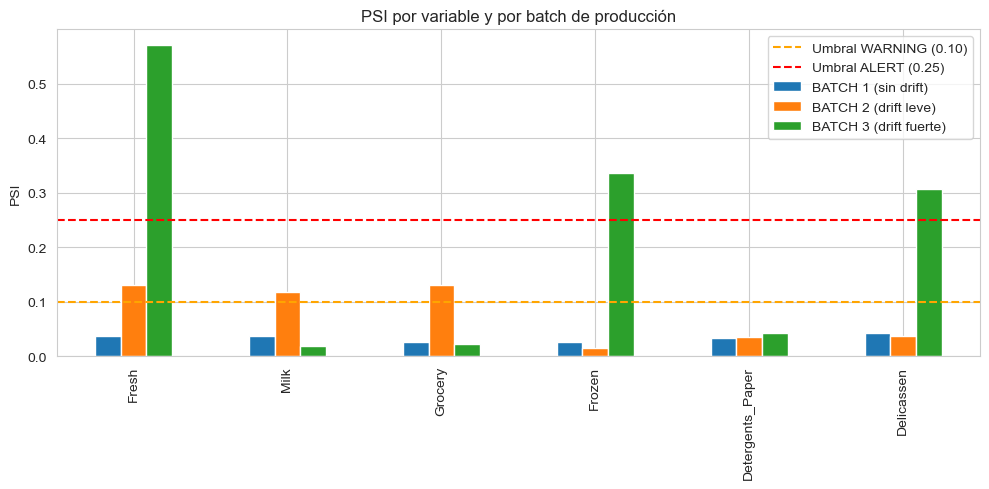

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
df_psi[COLS_GASTO].T.plot(kind="bar", ax=ax)
ax.axhline(0.10, color="orange", linestyle="--", label="Umbral WARNING (0.10)")
ax.axhline(0.25, color="red", linestyle="--", label="Umbral ALERT (0.25)")
ax.set_ylabel("PSI")
ax.set_title("PSI por variable y por batch de producción")
ax.legend()
plt.tight_layout()
plt.show()

### De Data Drift a Model Impact

El PSI (Sección O2) mide si cambió la distribución de las variables de entrada. Pero eso no dice automáticamente si el modelo se ve afectado — un cambio en `P(X)` podríano alterar en qué cluster cae cada cliente, si el cambio ocurre lejos de las fronteras de decisión. Aquí se aplica el modelo de producción a cada batch y se compara la distribución de clusters resultante contra la de REFERENCE, usando `comparar_distribuciones()` (Sección O3).

In [5]:
modelo, feature_builder = cargar_modelo()

dist_reference = obtener_distribucion_clusters(modelo, feature_builder, df_reference)
print(f"REFERENCE: {dist_reference}")

resultados_modelo = {}
for nombre_batch, df_batch in batches.items():
    dist_batch = obtener_distribucion_clusters(modelo, feature_builder, df_batch)
    comparacion = comparar_distribuciones(dist_reference, dist_batch)
    resultados_modelo[nombre_batch] = {
        "distribucion": dist_batch,
        "estable": comparacion["estable"],
        "diferencia_maxima_pp": comparacion["diferencia_maxima"],
    }
    print(f"\n{nombre_batch}: {dist_batch}")
    print(f"  Estable: {comparacion['estable']} (diferencia máxima: {comparacion['diferencia_maxima']}pp)")

REFERENCE: {0: 30.68, 1: 37.73, 2: 31.59}

BATCH 1 (sin drift): {0: 26.67, 1: 40.67, 2: 32.67}
  Estable: True (diferencia máxima: 4.01pp)

BATCH 2 (drift leve): {0: 27.33, 1: 40.67, 2: 32.0}
  Estable: True (diferencia máxima: 3.35pp)

BATCH 3 (drift fuerte): {0: 33.33, 1: 22.0, 2: 44.67}
  Estable: False (diferencia máxima: 15.73pp)


C:\Users\quesa\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\quesa\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\quesa\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.9.0 when using vers

**¿El data drift detectado se traduce en un cambio real del comportamiento del modelo?** 

Sí, y de forma proporcional al PSI observado: 

BATCH 1 (PSI=0.042, OK) y BATCH 2 (PSI=0.131, WARNING) mantienen el modelo estable (diferencias de 4.01pp y 3.35pp respectivamente, ambas bajo el umbral de 10pp) — el drift leve no alcanza a mover clientes entre clusters de forma significativa. 

BATCH 3 (PSI=0.571, ALERT) sí desestabiliza el modelo (15.73pp de diferencia máxima, superando el umbral): el cluster 1 pierde casi 16 puntos de participación (37.73% → 22.0%) mientras el cluster 2 gana un peso similar (31.59% → 44.67%). Esto es consistente con el diseño de BATCH 3 — el aumento fuerte en Fresh, Frozen y Delicassen desplaza clientes que antes caían en el perfil "retail/abarrotes" (cluster 1) hacia el perfil "Horeca diversificado" (cluster 2, caracterizado justamente por Frozen y Delicassen altos, según el análisis de perfiles del notebook 03).

En conjunto, esta progresión (OK/WARNING → modelo estable; ALERT → modelo inestable) es la evidencia empírica que sustenta el criterio de reentrenamiento propuesto en la Sección R: el PSI por sí solo no basta para decidir reentrenar, pero cuando se combina con un cambio real en el comportamiento del modelo (no solo en la distribución de entrada), sí hay una señal accionable.

## Sección Q — Simulación de Problemas de Calidad

Se inyectan los 6 tipos de defecto que exige el enunciado sobre una **copia** del dataset de referencia — el archivo original en `data/raw/` nunca se modifica. El objetivo es comprobar que `validar_calidad_datos()` (Secciones F-G) detecta cada uno de forma explícita, no accidental.

In [6]:
batch_contaminado = df_reference.copy()

# 1. Missing values
batch_contaminado.loc[0, "Fresh"] = np.nan
batch_contaminado.loc[1, "Milk"] = np.nan

# 2. Duplicated rows
batch_contaminado = pd.concat(
    [batch_contaminado, batch_contaminado.iloc[[0]]], ignore_index=True
)

# 3. Extreme outlier (dato imposible: gasto negativo)
batch_contaminado.loc[5, "Frozen"] = -500000

# 4. Incorrect datatype
batch_contaminado.loc[7, "Detergents_Paper"] = "noventa"

# 5. Unknown category
batch_contaminado.loc[10, "Channel"] = 99

# 6. Schema modification
batch_contaminado["columna_falsa"] = "dato_incorrecto"

print(f"Batch contaminado: {batch_contaminado.shape[0]} filas, {batch_contaminado.shape[1]} columnas")
print(f"REFERENCE (sin tocar): {df_reference.shape[0]} filas, {df_reference.shape[1]} columnas")

Batch contaminado: 441 filas, 9 columnas
REFERENCE (sin tocar): 440 filas, 8 columnas


C:\Users\quesa\AppData\Local\Temp\ipykernel_1908\3385366814.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'noventa' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  batch_contaminado.loc[7, "Detergents_Paper"] = "noventa"


In [7]:
# --- DETECTA: cada regla evalúa el batch de forma independiente ---
reporte_contaminado = validar_calidad_datos(batch_contaminado, COLS_GASTO)

for regla, resultado in reporte_contaminado.items():
    estado = "✅ PASS" if resultado["pass"] else "❌ FAIL"
    print(f"{estado} | {regla}: {resultado['detalle']}")

todas_pasaron = all(r["pass"] for r in reporte_contaminado.values())

# --- BLOQUEA/ADVIERTE: mismo patrón que usa train.py antes de entrenar ---
print(f"\nResultado global: {'PASS ✅' if todas_pasaron else 'FAIL ❌'}")
try:
    assert todas_pasaron, "Data Quality Gates falló — el pipeline NO debe continuar con este batch."
except AssertionError as exc:
    # --- REGISTRA: se deja constancia del incidente sin interrumpir el notebook ---
    print(f"\n🛑 Pipeline bloqueado: {exc}")

# El batch contaminado se descarta; el dataset original nunca se modificó.
del batch_contaminado
print(f"\nBatch contaminado descartado. REFERENCE sigue intacto: {df_reference.shape}")

✅ PASS | min_rows: 441 filas (esperado: >= 396, 90% del histórico)
❌ FAIL | sin_nulos_obligatorios: 3 valores nulos en columnas obligatorias
✅ PASS | duplicados_bajo_umbral: 0.23% de filas duplicadas (umbral: 2%)
❌ FAIL | tipos_numericos_validos: Columnas con tipo no numérico: ['Detergents_Paper']
❌ FAIL | sin_gastos_negativos: 1 valores negativos en variables de gasto
❌ FAIL | cardinalidad_categorica_valida: Channel válido: False, Region válido: True
❌ FAIL | esquema_sin_columnas_extra: Columnas inesperadas: ['columna_falsa']

Resultado global: FAIL ❌

🛑 Pipeline bloqueado: Data Quality Gates falló — el pipeline NO debe continuar con este batch.

Batch contaminado descartado. REFERENCE sigue intacto: (440, 8)


### Mapeo de defectos inyectados a reglas que los detectaron

| Defecto inyectado | Regla que lo evalúa | Resultado |
|---|---|---|
| Missing values (Fresh, Milk) | `sin_nulos_obligatorios` | ❌ FAIL — detectado |
| Fila duplicada | `duplicados_bajo_umbral` | ✅ PASS — presente (0.23%) pero bajo el umbral tolerado (2%) |
| Outlier extremo (Frozen=-500000) | `sin_gastos_negativos` | ❌ FAIL — detectado |
| Tipo incorrecto (texto en Detergents_Paper) | `tipos_numericos_validos` | ❌ FAIL — detectado |
| Categoría desconocida (Channel=99) | `cardinalidad_categorica_valida` | ❌ FAIL — detectado |
| Columna extra (columna_falsa) | `esquema_sin_columnas_extra` | ❌ FAIL — detectado |

5 de los 6 defectos inyectados dispararon un `FAIL` explícito. El caso de la fila duplicada es distinto pero no un fallo del sistema: con solo 1 duplicado en 441 filas (0.23%), el porcentaje se mantiene por debajo del umbral de 2% que se justificó previamente en la Sección G con evidencia real (0% de duplicados en el dataset histórico). El sistema sí "vio" el duplicado — el detalle del reporte lo refleja explícitamente — simplemente no lo consideró suficiente para bloquear por sí solo, que es el comportamiento esperado de un umbral con tolerancia, no un umbral binario.

En conjunto, el pipeline bloqueó correctamente el batch contaminado (5 de 7 reglas en FAIL, resultado global FAIL), demostrando el ciclo completo **Detecta → Bloquea/Advierte → Registra** exigido por la Sección Q, sin modificar el dataset original en ningún momento (`REFERENCE` se mantuvo en 440 filas después de la prueba).

## Sección R — Estrategia de Reentrenamiento

Se aplica `evaluar_necesidad_reentrenamiento()` sobre los 3 batches ya construidos en la Sección P, calculando el silhouette real de cada uno con el modelo de producción (no un valor inventado), para demostrar la lógica con evidencia concreta en vez de un ejemplo hipotético.

In [8]:
from sklearn.metrics import silhouette_score

from src.monitoring.retrain_trigger import evaluar_necesidad_reentrenamiento

resultados_reentrenamiento = {}
for nombre_batch, df_batch in batches.items():
    df_features_batch = feature_builder.transform(df_batch)
    X_batch = df_features_batch[feature_builder.cols_finales_]
    labels_batch = modelo.predict(X_batch)
    silhouette_batch = silhouette_score(X_batch, labels_batch)

    resultado = evaluar_necesidad_reentrenamiento(
        df_reference, df_batch, silhouette_batch, modelo, feature_builder
    )
    resultados_reentrenamiento[nombre_batch] = resultado
    print(f"{nombre_batch}: {resultado}")

BATCH 1 (sin drift): {'decision': 'OK', 'psi_max': 0.042, 'silhouette_actual': np.float64(0.2575), 'umbral_silhouette': 0.1796, 'diferencia_composicion_pp': 4.01, 'drift_alto': False, 'performance_baja': np.False_, 'modelo_inestable': False}
BATCH 2 (drift leve): {'decision': 'OK', 'psi_max': 0.1312, 'silhouette_actual': np.float64(0.2535), 'umbral_silhouette': 0.1796, 'diferencia_composicion_pp': 3.35, 'drift_alto': False, 'performance_baja': np.False_, 'modelo_inestable': False}
BATCH 3 (drift fuerte): {'decision': 'REENTRENAR', 'psi_max': 0.5708, 'silhouette_actual': np.float64(0.2083), 'umbral_silhouette': 0.1796, 'diferencia_composicion_pp': 15.73, 'drift_alto': True, 'performance_baja': np.False_, 'modelo_inestable': True}


**¿Cuándo dispara reentrenamiento el sistema?** 

BATCH 1 y BATCH 2 (drift nulo/leve) quedan en OK, sin ninguna señal de alarma — consistente con la Sección P, donde ambos mantuvieron el modelo estable. BATCH 3 dispara REENTRENAR, pero por una razón que no era la esperada inicialmente: **no** fue por caída de silhouette (0.2083, todavía por encima del umbral 0.1796 — una caída de solo ~19%), sino por **inestabilidad de composición de clusters** (15.73pp, muy por encima del umbral de 10pp).

Este resultado es evidencia directa de por qué el sistema necesita más de una señal de "performance": el silhouette mide qué tan bien separados están los clusters entre sí, pero no si los mismos tipos de cliente siguen cayendo en el mismo cluster que antes. Un modelo puede seguir produciendo agrupaciones geométricamente razonables (buen silhouette) mientras la composición de negocio detrás de esos grupos cambia sustancialmente — que es justo lo que se observó en BATCH 3 (Sección O3): el cluster "retail/abarrotes" perdió casi 16 puntos porcentuales de participación hacia el cluster "Horeca diversificado". Confiar solo en silhouette habría dejado pasar este caso sin disparar alerta.

**Drift ≠ Degradación, con evidencia de los tres niveles:**

BATCH 2 demuestra que drift real (PSI=0.131, WARNING) no implica degradación (modelo estable, decisión OK) — el sistema correctamente no reentrena solo porque cambió la distribución de entrada. 

BATCH 3 demuestra el caso contrario: drift severo que sí se traduce en degradación real (composición de clusters inestable), y ahí el sistema sí actúa. La razón por la que no se reentrena automáticamente solo con PSI alto es que un cambio de distribución puede ser legítimo y no dañino (ej. estacionalidad, una promoción puntual) — reentrenar en cada uno de esos casos desperdiciaría cómputo y arriesgaría introducir inestabilidad en el modelo sin necesidad real.